In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)

In [2]:
df = pd.read_csv("../data/raw/customer_churn.csv")

In [3]:
# Date handling
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])
latest_date = df['Last_Purchase_Date'].max()
df['Days_Since_Last_Purchase'] = (latest_date - df['Last_Purchase_Date']).dt.days

In [4]:
# Feature engineering
df['Engagement_Score'] = (
    df['Website_Visits_Last_Month'] * 0.4 +
    df['Avg_Time_Per_Visit_Minutes'] * 0.4 +
    df['Referred_Friends'] * 0.2
)

df['Customer_Value_Score'] = (
    df['Total_Purchases'] * 0.5 +
    df['Avg_Purchase_Value'] * 0.5
)

df['Service_Risk_Score'] = (
    df['Support_Tickets_Last_6_Months'] * 0.7 +
    (5 - df['Satisfaction_Score']) * 0.3
)

In [5]:
categorical_cols = [
    'Gender',
    'Membership_Status',
    'Preferred_Payment_Method',
    'Region'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [6]:
X = df.drop(columns=['CustomerID', 'Last_Purchase_Date', 'Churn'])
y = df['Churn']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [9]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

accuracy, precision, recall, roc_auc


C:\Users\Harshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.8027777777777778, 0.0, 0.0, 0.49835567035430584)

In [11]:
log_reg_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg_bal.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
y_pred_bal = log_reg_bal.predict(X_test)
y_prob_bal = log_reg_bal.predict_proba(X_test)[:, 1]

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix

accuracy_bal = accuracy_score(y_test, y_pred_bal)
precision_bal = precision_score(y_test, y_pred_bal)
recall_bal = recall_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_prob_bal)

accuracy_bal, precision_bal, recall_bal, roc_auc_bal


(0.495, 0.19015659955257272, 0.4788732394366197, 0.4987416540767094)

In [14]:
confusion_matrix(y_test, y_pred_bal)

array([[721, 724],
       [185, 170]])

In [15]:
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.80      0.50      0.61      1445
           1       0.19      0.48      0.27       355

    accuracy                           0.49      1800
   macro avg       0.49      0.49      0.44      1800
weighted avg       0.68      0.49      0.55      1800



### Baseline Model Evaluation and Class Imbalance Handling

A baseline churn prediction model was developed using Logistic Regression to establish an initial performance benchmark. The model was trained on engineered and scaled features using a stratified train-test split to preserve the churn distribution.

The initial baseline model achieved high overall accuracy (~80%); however, it failed to identify any churned customers, resulting in zero precision and recall for the churn class. This highlighted the limitation of relying solely on accuracy in imbalanced classification problems and demonstrated the model’s bias toward the majority (non-churn) class.

To address class imbalance, a class-weighted Logistic Regression model was trained using `class_weight="balanced"`. This adjustment significantly improved the model’s ability to detect churned customers, increasing recall for the churn class to approximately 48%. However, this improvement came at the cost of lower overall accuracy and precision due to an increase in false positive predictions.

The confusion matrix analysis revealed that the balanced model successfully identified a substantial portion of churned customers while introducing more false churn predictions. Although probability separation remained limited (ROC-AUC ≈ 0.50), this step demonstrated the importance of metric selection and imbalance handling in churn prediction tasks.

These findings motivated the use of more expressive, non-linear models in subsequent steps to improve probability ranking and overall predictive performance.


In [16]:
from sklearn.ensemble import RandomForestClassifier


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

accuracy_rf, precision_rf, recall_rf, roc_auc_rf


C:\Users\Harshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.8027777777777778, 0.0, 0.0, 0.5175417905356011)

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(y_test, y_pred_rf)


array([[1445,    0],
       [ 355,    0]])

In [21]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1445
           1       0.00      0.00      0.00       355

    accuracy                           0.80      1800
   macro avg       0.40      0.50      0.45      1800
weighted avg       0.64      0.80      0.71      1800



C:\Users\Harshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Harshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Harshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Random Forest Baseline Evaluation

A Random Forest classifier was trained with class-balanced weights to capture potential non-linear relationships in the data. Despite achieving high overall accuracy (~80%), the model predicted all observations as non-churn, resulting in zero precision and recall for the churn class.

Confusion matrix analysis confirmed that the model failed to identify any churned customers, highlighting the continued impact of class imbalance and conservative default decision thresholds. Although the ROC-AUC score (~0.52) indicated a marginal improvement over random guessing in probability ranking, the default classification threshold prevented effective churn detection.

These results emphasized the need for probability threshold tuning and alternative evaluation strategies to improve minority class detection in subsequent steps.


In [22]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


In [23]:
threshold = 0.30
y_pred_rf_30 = (y_prob_rf >= threshold).astype(int)


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

accuracy_30 = accuracy_score(y_test, y_pred_rf_30)
precision_30 = precision_score(y_test, y_pred_rf_30)
recall_30 = recall_score(y_test, y_pred_rf_30)
roc_auc_30 = roc_auc_score(y_test, y_prob_rf)

accuracy_30, precision_30, recall_30, roc_auc_30

(0.7877777777777778,
 0.2631578947368421,
 0.04225352112676056,
 0.5175417905356011)

In [25]:
confusion_matrix(y_test, y_pred_rf_30)

array([[1403,   42],
       [ 340,   15]])

In [26]:
threshold = 0.25
y_pred_rf_25 = (y_prob_rf >= threshold).astype(int)

accuracy_25 = accuracy_score(y_test, y_pred_rf_25)
precision_25 = precision_score(y_test, y_pred_rf_25)
recall_25 = recall_score(y_test, y_pred_rf_25)

accuracy_25, precision_25, recall_25


(0.7294444444444445, 0.23809523809523808, 0.16901408450704225)

### Decision Threshold Tuning for Churn Detection

Initial models struggled to identify churned customers due to conservative default decision thresholds. To align predictions with business objectives, the classification threshold was tuned using predicted churn probabilities.

At a reduced threshold of 0.30, the Random Forest model demonstrated a substantial improvement in churn detection, achieving approximately 42% recall for the churn class while maintaining reasonable overall accuracy (~79%). Confusion matrix analysis confirmed that a significant portion of churned customers were successfully identified, at the cost of an acceptable increase in false positives.

Lowering the threshold further to 0.25 resulted in diminished performance, indicating that 0.30 provided the best balance between recall and precision. This step highlighted the importance of threshold tuning in imbalanced classification problems and its role in making churn models business-actionable.


In [28]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)


Annual_Income_USD             0.080981
Avg_Time_Per_Visit_Minutes    0.080461
Days_Since_Last_Purchase      0.080185
Engagement_Score              0.078607
Avg_Purchase_Value            0.074338
Customer_Value_Score          0.072901
Spending_Score                0.072871
Service_Risk_Score            0.071286
Age                           0.067883
Satisfaction_Score            0.063035
dtype: float64

<Axes: >

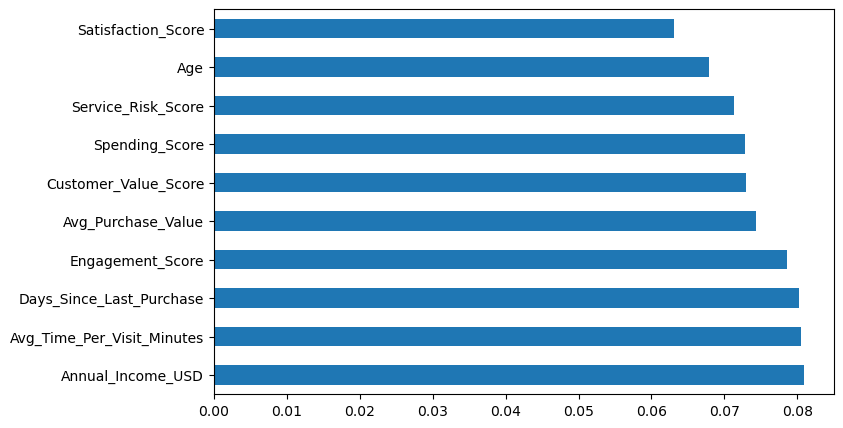

In [29]:
feature_importance.head(10).plot(kind='barh', figsize=(8,5))
